# Nifty 50 Stock Market Prediction

Shri Havish Aele (142301003)


Vivek (142301024)


Varun (142301040)


Saideep (112301018)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')


# Load dataset

In [2]:
df = pd.read_csv("HDFCBANK.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# Clean infinities before modeling/plotting
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

stock_name = df.iloc[0]['Symbol']

# Feature Engineering

In [3]:
df["Target"] = df["Close"].shift(-1)   # predict next day's close
df = df.dropna()

features = ["Open", "High", "Low", "Last", "Turnover"]
X = df[features]
y = df["Target"]

# EDA

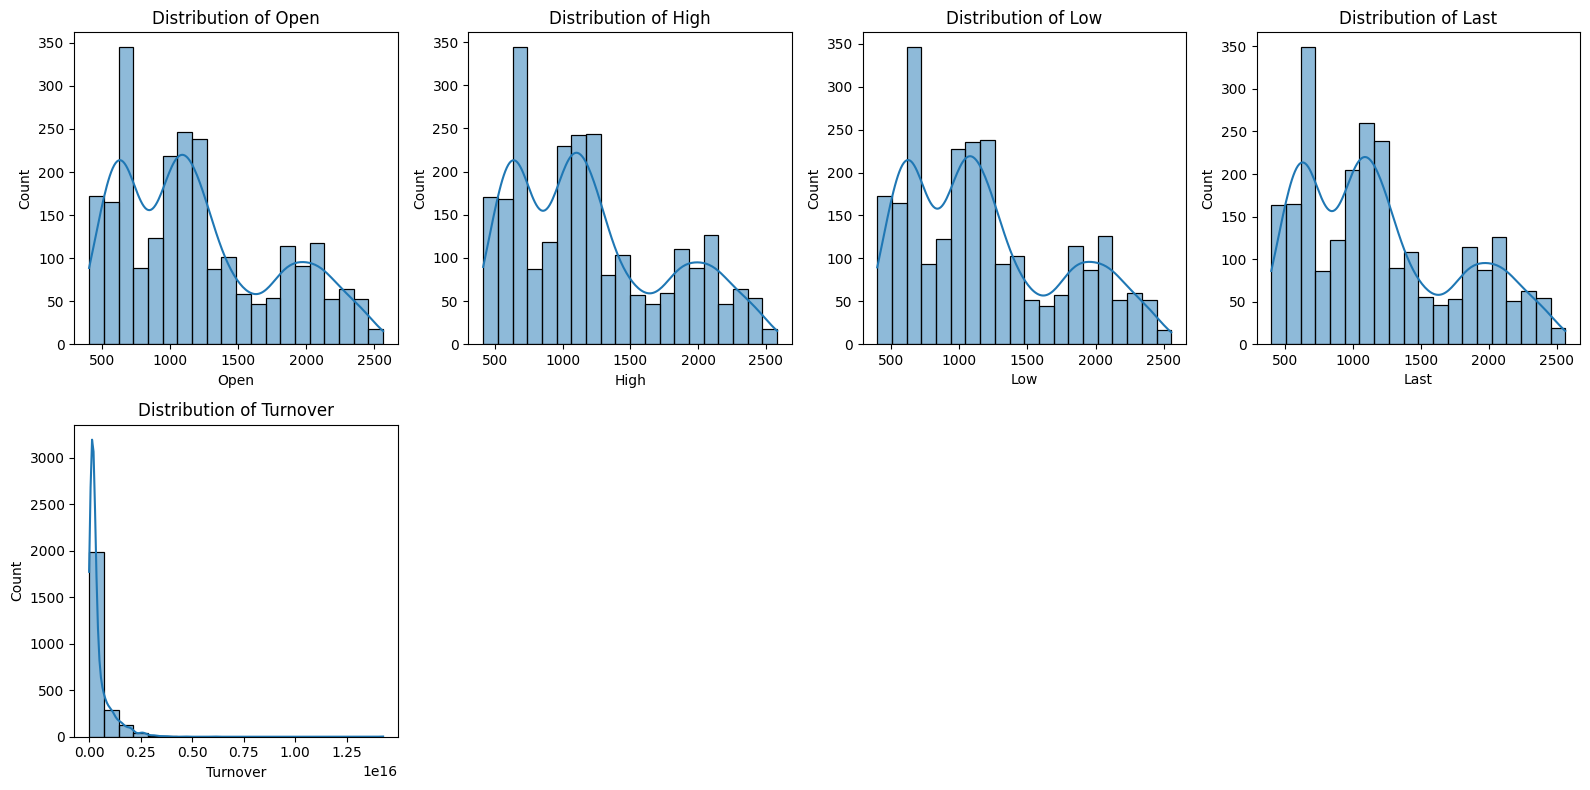

In [4]:
features = ["Open", "High", "Low", "Last", "Turnover"]

num_columns = len(features)
num_rows = (num_columns // 4) + (1 if num_columns % 4 != 0 else 0)  # 4 columns per row

# Plotting histograms for the selected features
plt.figure(figsize=(16, 4 * num_rows))  
for i, column in enumerate(features):
    plt.subplot(num_rows, 4, i + 1)  # Dynamic grid (4 columns per row)
    sns.histplot(df[column], kde=True, bins=20)
    plt.title(f'Distribution of {column}')
plt.tight_layout()
plt.show()

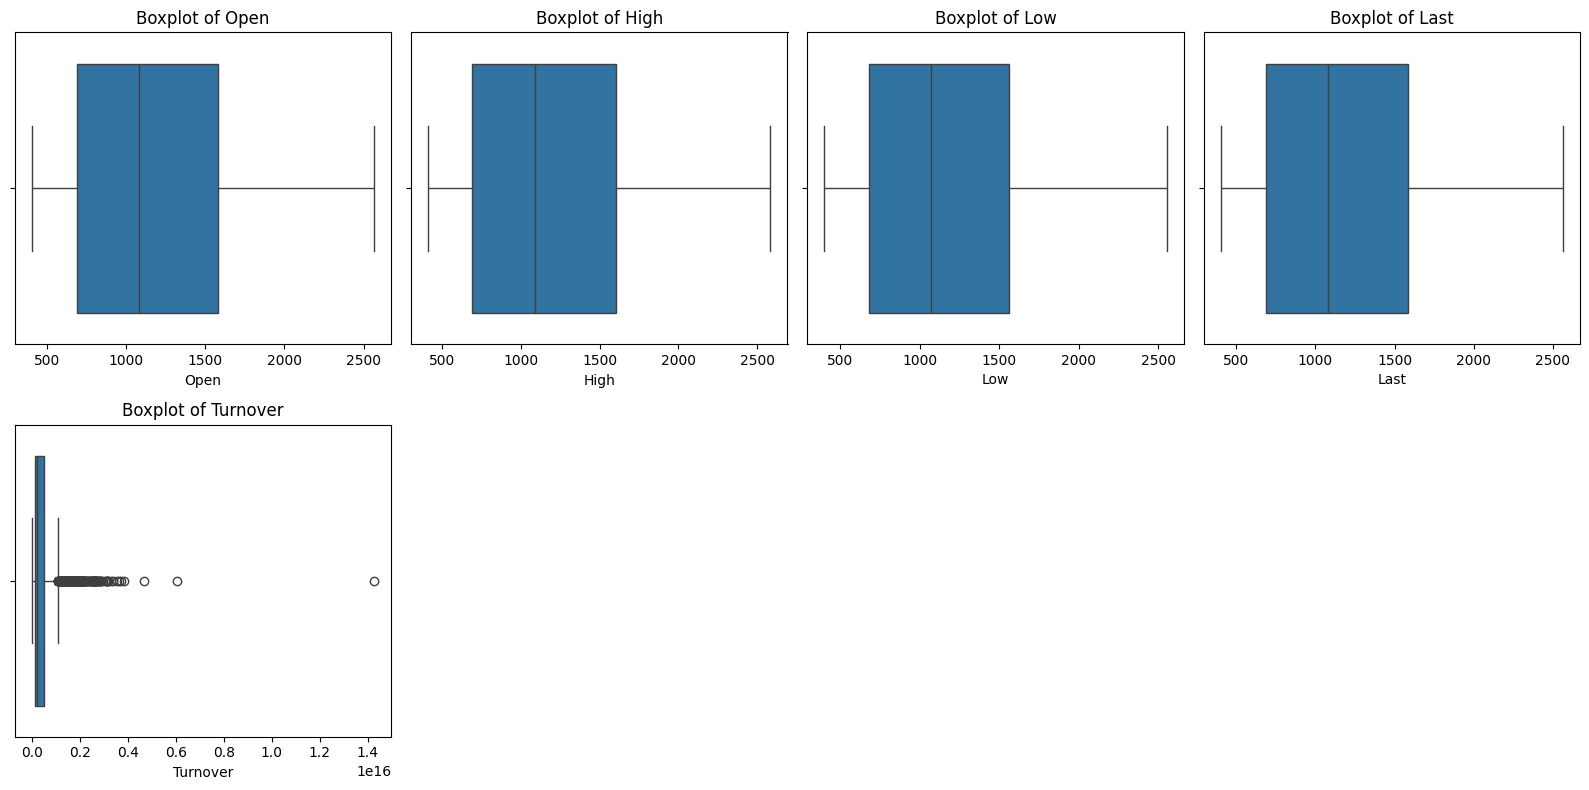

In [5]:
num_features = len(features)
num_rows = (num_features // 4) + (1 if num_features % 4 != 0 else 0)

plt.figure(figsize=(16, 4 * num_rows))  # Adjust figure size dynamically

# Plotting boxplots for the selected features
for i, column in enumerate(features):
    plt.subplot(num_rows, 4, i + 1)  # 4 columns per row
    sns.boxplot(data=df, x=column)
    plt.title(f'Boxplot of {column}')

plt.tight_layout()
plt.show()

# Train/Test Split

In [6]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
dates_test = df["Date"].iloc[train_size:]

# Scale features (for SVR, KNN)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter Tuning


Tuning parameter for models:
- Support Vector Regression
- KNN Regression

In [8]:

# Support Vector Regression
svr_params = {
    "C": [0.1, 1, 10, 50],
    "epsilon": [0.01, 0.1, 0.5, 1],
    "kernel": ["poly"],  # polynomial kernel
    "degree": [2, 3, 4]
}

svr_grid = GridSearchCV(
    SVR(),
    svr_params,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    verbose=1
)
svr_grid.fit(X_train_scaled, y_train)

best_svr = svr_grid.best_estimator_
print("Best SVR Parameters:", svr_grid.best_params_)

# Evaluate SVR 
svr_pred = best_svr.predict(X_test_scaled)
svr_r2 = r2_score(y_test, svr_pred)
svr_mae = mean_absolute_error(y_test, svr_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_pred))

print("\nSVR Performance:")
print(f"R2 Score: {svr_r2:.4f}")
print(f"MAE: {svr_mae:.4f}")
print(f"RMSE: {svr_rmse:.4f}")


# K-Nearest Neighbors Regression
knn_params = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "p": [1, 2]  # 1=Manhattan, 2=Euclidean
}

knn_grid = GridSearchCV(
    KNeighborsRegressor(),
    knn_params,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    verbose=1
)
knn_grid.fit(X_train_scaled, y_train)

best_knn = knn_grid.best_estimator_
print("\nBest KNN Parameters:", knn_grid.best_params_)

# Evaluate KNN 
knn_pred = best_knn.predict(X_test_scaled)
knn_r2 = r2_score(y_test, knn_pred)
knn_mae = mean_absolute_error(y_test, knn_pred)
knn_rmse = np.sqrt(mean_squared_error(y_test, knn_pred))

print("\nKNN Performance:")
print(f"R2 Score: {knn_r2:.4f}")
print(f"MAE: {knn_mae:.4f}")
print(f"RMSE: {knn_rmse:.4f}")




Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best SVR Parameters: {'C': 0.1, 'degree': 3, 'epsilon': 1, 'kernel': 'poly'}

SVR Performance:
R2 Score: 0.7215
MAE: 207.9150
RMSE: 246.5321
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best KNN Parameters: {'n_neighbors': 3, 'p': 1, 'weights': 'distance'}

KNN Performance:
R2 Score: 0.9712
MAE: 47.6037
RMSE: 79.2860


# Models

In [9]:
models = {
    "Multiple Linear Regression": LinearRegression(),
    "Random Forest Regression": RandomForestRegressor(),  
    "Support Vector Regression": SVR(kernel="poly", degree=3, C=0.1, epsilon=1),
    "Bayesian Linear Regression": BayesianRidge(),
    "KNN Regression": KNeighborsRegressor(n_neighbors=3, weights="distance", p=1)
}


# Train, Predict, Evaluate


In [10]:
results = []
predictions = {}

for name, model in models.items():
    if name in ["Support Vector Regression", "KNN Regression"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    accuracy = r2 * 100   

    results.append([name, mae, rmse, r2, accuracy])
    predictions[name] = y_pred

In [11]:
# Results table
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2 Score", "Accuracy (%)"])
print("\nModel Comparison Results:\n")
print(results_df)


Model Comparison Results:

                        Model         MAE        RMSE  R2 Score  Accuracy (%)
0  Multiple Linear Regression   22.662778   57.301394  0.984956     98.495610
1    Random Forest Regression   25.417414   58.601432  0.984266     98.426574
2   Support Vector Regression  207.914982  246.532146  0.721531     72.153087
3  Bayesian Linear Regression   21.820849   56.220706  0.985518     98.551820
4              KNN Regression   47.603740   79.285980  0.971198     97.119799


### Bayesian Linear Regression performed best overall with highest R² (0.9856) and lowest error, making it the most accurate and reliable model for stock price prediction.



# Visualization


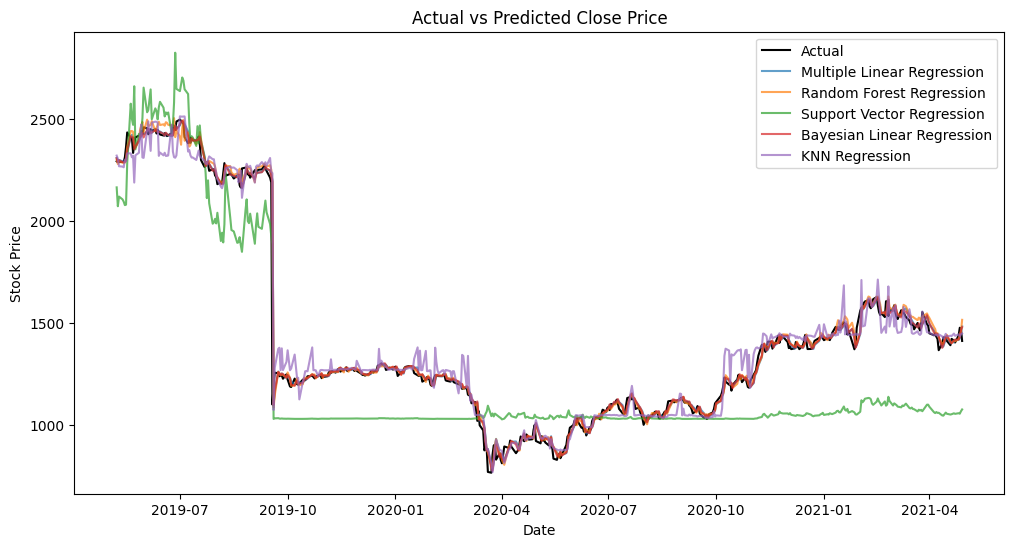

In [12]:
# Plot actual vs predicted for each model
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test, label="Actual", color="black")

for name, y_pred in predictions.items():
    plt.plot(dates_test, y_pred, label=name, alpha=0.7)

plt.title("Actual vs Predicted Close Price")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

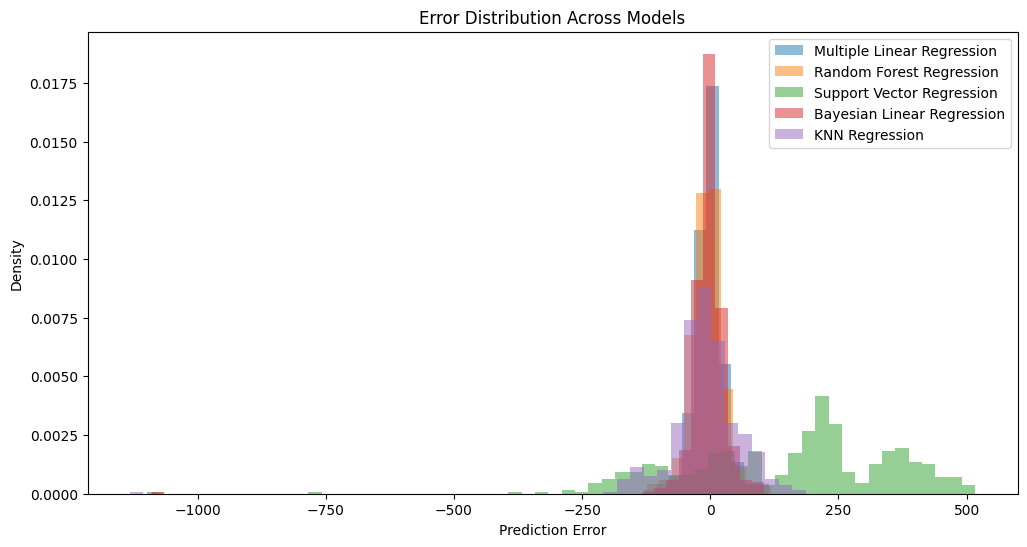

In [13]:
# Error distribution plots using Matplotlib
plt.figure(figsize=(12, 6))
for name, y_pred in predictions.items():
    errors = y_test - y_pred
    plt.hist(errors, bins=50, alpha=0.5, label=name, density=True)

plt.title("Error Distribution Across Models")
plt.xlabel("Prediction Error")
plt.ylabel("Density")
plt.legend()
plt.show()

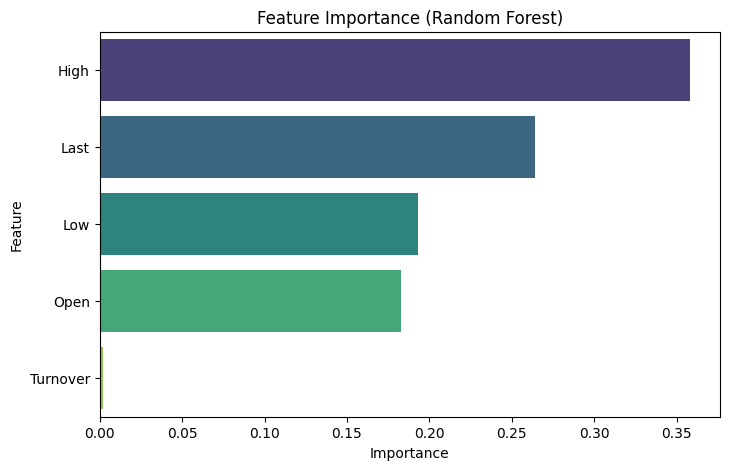

In [14]:
# Feature importance (Random Forest only)
rf_model = models["Random Forest Regression"]
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({"Feature": features, "Importance": importances})
feat_imp = feat_imp.sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x="Importance", y="Feature", data=feat_imp, palette="viridis")
plt.title("Feature Importance (Random Forest)")
plt.show()

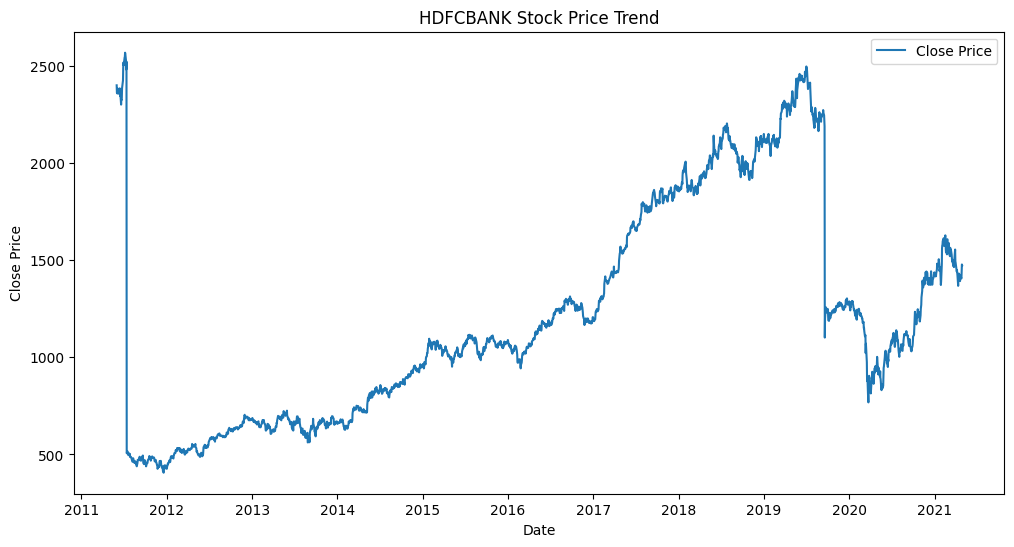

In [15]:
# Historical stock price trend
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Close"], label="Close Price")
plt.title(f"{stock_name} Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()


# Predict for New Sample


In [16]:
# Example new sample (replace with real/latest values)
# Format must match: ["Open", "High", "Low", "Last", "Close", "Turnover"]
new_sample = pd.DataFrame([[1510, 1525, 1498, 1505, 12000000]], 
                          columns=features)

print("\nNew Sample:\n", new_sample)

# Scale for models that require scaling
new_sample_scaled = scaler.transform(new_sample)


# Store predictions
new_predictions = {}

for name, model in models.items():
    if name in ["Support Vector Regression", "KNN Regression"]:
        pred = model.predict(new_sample_scaled)[0]
    else:
        pred = model.predict(new_sample)[0]
    
    new_predictions[name] = pred

# Convert predictions to DataFrame
predictions_df = pd.DataFrame(
    list(new_predictions.items()),
    columns=["Model", "Predicted Close Price"]
)

print("\nPredictions for New Sample:\n")
print(predictions_df)


New Sample:
    Open  High   Low  Last  Turnover
0  1510  1525  1498  1505  12000000

Predictions for New Sample:

                        Model  Predicted Close Price
0  Multiple Linear Regression            1507.814321
1    Random Forest Regression            1535.365500
2   Support Vector Regression            1056.362645
3  Bayesian Linear Regression            1503.911714
4              KNN Regression            1538.598050
